In [1]:
# import os

# # Install Kaggle API client
# !pip install kaggle

# # Ensure kaggle.json is in the correct directory for authentication
# # This is typically done by uploading kaggle.json to /content/ or ~/.kaggle/
# # Given kaggle.json is listed in /content/, we assume it's set up.

# # Set permissions for the kaggle.json file
# !mkdir -p ~/.kaggle
# !cp /content/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [2]:
# # Download the dataset from Kaggle
# # Dataset: abdoamrrrr/rode-and-tube-1
# !kaggle datasets download -d abdoamrrrr/rode-and-tube-1 -p /content/

# # Unzip the downloaded file
# # The downloaded file will likely be named 'rode-and-tube-1.zip'
# zip_file_path = '/content/rode-and-tube-1.zip'
# extract_to_directory = '/content/'

# import zipfile
# import os

# if os.path.exists(zip_file_path):
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_to_directory)
#     print(f"✅ Successfully extracted {zip_file_path} to {extract_to_directory}")
#     # List files to verify extraction and find the CSV name
#     print("Files in extraction directory:")
#     print(os.listdir(extract_to_directory))
# else:
#     print(f"❌ Zip file not found: {zip_file_path}")

In [3]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers



2026-05-14 22:04:04.666753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778796244.869173      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778796244.922032      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778796245.395736      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778796245.395775      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778796245.395778      57 computation_placer.cc:177] computation placer alr

In [4]:
# Define column names based on geometric dimensions
DIM_NAMES = ['Length', 'Diameter', 'Core_Diameter', 'Rod_Diameter',
             'Support_Diameter', 'Throat_Diameter', 'Exit_Diameter']
NUM_POINTS = 100

def process_data_inverse(file_path, num_points=NUM_POINTS):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')

    # Read data while skipping bad lines
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True, low_memory=False)
    df.columns = df.columns.str.strip()

    # Convert columns to numeric and drop missing values
    target_cols = ['ID', 'Time (s)', 'Thrust (N)', 'Pressure (MPa)'] + DIM_NAMES
    for col in target_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)

    ids = df['ID'].unique()
    X_profiles = []   # Will contain (100 Thrust points + 100 Pressure points)
    y_dims = []       # Will contain the 7 geometric dimensions

    for uid in ids:
        try:
            case_data = df[df['ID'] == uid].sort_values('Time (s)')
            dims = case_data[DIM_NAMES].iloc[0].values.astype(float)

            t = case_data['Time (s)'].values
            thrust = case_data['Thrust (N)'].values
            pressure = case_data['Pressure (MPa)'].values

            if len(t) < 10 or t[-1] <= 0: continue

            # Smooth curves using Savgol filter
            thrust = savgol_filter(thrust, 7, 3)
            pressure = savgol_filter(pressure, 7, 3)

            # Uniform point distribution over time
            t_new = np.linspace(t[0], t[-1], num_points)
            thrust_interp = interp1d(t, thrust, kind='linear', fill_value='extrapolate')(t_new)
            pressure_interp = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(t_new)

            # Concatenate both curves into one array (length 200)
            X_profiles.append(np.concatenate([thrust_interp, pressure_interp]))
            y_dims.append(dims)
        except:
            continue

    return np.array(X_profiles), np.array(y_dims)

# Execute processing
FILE_PATH = '/kaggle/input/datasets/abdoamrrrr/new-roda-and-tube/Rocket_Results_Full_Data.csv'
X_all, y_all = process_data_inverse(FILE_PATH)

print(f"X shape (Input Curves): {X_all.shape}")
print(f"y shape (Output Dimensions): {y_all.shape}")

X shape (Input Curves): (3720, 200)
y shape (Output Dimensions): (3720, 7)


In [5]:
df=pd.read_csv("/kaggle/input/datasets/abdoamrrrr/new-roda-and-tube/Rocket_Results_Full_Data.csv")
df.tail()

,Time (s),Pressure (MPa),Thrust (N),ID,Length,Diameter,Core_Diameter,Rod_Diameter,Support_Diameter,Throat_Diameter,Exit_Diameter,Total Impulse (Ns),ISP (s),Max Thrust (N),Peak Pressure (MPa),Burn Time (s),Avg Thrust (N)
4651165,8.460,45.8787,41341.2881,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651166,8.465,45.9463,41402.4511,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651167,8.470,46.0141,41463.6953,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651168,8.475,46.0819,41525.0207,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651169,8.480,0.0000,0.0000,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42
)

# Use RobustScaler for input curves and StandardScaler for output dimensions
scaler_X = RobustScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_test_s  = scaler_y.transform(y_test)

# Save scalers for future predictions
joblib.dump(scaler_X, 'scaler_X_inverse.pkl')
joblib.dump(scaler_y, 'scaler_y_inverse.pkl')

print("Data scaling completed and scalers saved.")

Data scaling completed and scalers saved.


In [7]:
def build_inverse_model(input_dim=200, output_dim=7):
    inp = layers.Input(shape=(input_dim,), name='Curves_Input')

    # 1D-CNN Branch for feature extraction from curves
    #
    x = layers.Reshape((input_dim, 1))(inp)
    x = layers.Conv1D(64, 7, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Residual Block 1 (Dense)
    res1 = layers.Dense(512, activation='relu')(x)
    res1 = layers.BatchNormalization()(res1)
    res1 = layers.Dense(512, activation='relu')(res1)
    shortcut1 = layers.Dense(512)(x)
    x = layers.Add()([shortcut1, res1])
    x = layers.Dropout(0.2)(x)

    # Residual Block 2 (Dense)
    res2 = layers.Dense(512, activation='relu')(x)
    res2 = layers.BatchNormalization()(res2)
    res2 = layers.Dense(512, activation='relu')(res2)
    shortcut2 = layers.Dense(512)(x)
    x = layers.Add()([shortcut2, res2])
    x = layers.Dropout(0.2)(x)

    # Create separate heads for each geometric dimension
    heads = []
    for i, name in enumerate(DIM_NAMES):
        h = layers.Dense(64, activation='relu', name=f'head_{i}')(x)
        h = layers.Dense(1, name=f'out_{i}')(h)
        heads.append(h)

    # Concatenate all outputs into one vector
    out = layers.Concatenate(name='Dimensions_Output')(heads)

    model = models.Model(inputs=inp, outputs=out, name='Inverse_Rocket_Model')
    return model

model_inverse = build_inverse_model()
model_inverse.compile(optimizer=optimizers.Adam(0.001), loss='huber', metrics=['mae'])
model_inverse.summary()

I0000 00:00:1778796306.292660      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778796306.298401      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Inverse_Rocket_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Curves_Input        │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 200, 1)    │          0 │ Curves_Input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 64)   │        512 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 128)  │     41,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 256)  │     98,560 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv1d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dense_2[0][0],    │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512)       │          0 │ dense_5[0][0],    │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_0 (Dense)      │ (None, 64)        │     32,832 │ dropout_1[0][0] 

 Total params: 1,689,095 (6.44 MB)

 Trainable params: 1,686,663 (6.43 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [8]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
lr_red = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6)

print("Starting training of Inverse Model...")
history = model_inverse.fit(
    X_train_s, y_train_s,
    validation_split=0.15,
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop, lr_red],
    verbose=1
)

Starting training of Inverse Model...
Epoch 1/1000


I0000 00:00:1778796313.925489     130 service.cc:152] XLA service 0x7dc2d80322a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778796313.925526     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778796313.925529     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778796315.208175     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-14 22:05:17.407084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 22:05:17.609701: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.3 = (f32[32,64,1,200]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,1,200]{3,2,1,0} %bitcast.14227, f32[128,64,1,5]{3,2,1,0} %bitcast.138

21/84 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7000 - mae: 1.0963 

I0000 00:00:1778796321.699422     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - loss: 0.5096 - mae: 0.8737 - val_loss: 0.3712 - val_mae: 0.7055 - learning_rate: 0.0010
Epoch 2/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2343 - mae: 0.5247 - val_loss: 0.3866 - val_mae: 0.7189 - learning_rate: 0.0010
Epoch 3/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1790 - mae: 0.4350 - val_loss: 0.3585 - val_mae: 0.6849 - learning_rate: 0.0010
Epoch 4/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1662 - mae: 0.4158 - val_loss: 0.3158 - val_mae: 0.6319 - learning_rate: 0.0010
Epoch 5/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1570 - mae: 0.3979 - val_loss: 0.3223 - val_mae: 0.6334 - learning_rate: 0.0010
Epoch 6/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1558 - mae: 0.3957 - val_loss: 0.1781 - val_mae: 0.4443 - learning_rate: 0.0010
Epoch 7/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1428 - mae: 0.3720 - val_loss: 0.1594 - val_mae: 0.4140 - learning_rate: 0.0010
Epoch 8/1000
84/8

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step 

Accuracy Summary (MAPE per Dimension):
- Length              : 1.34%
- Diameter            : 1.23%
- Core_Diameter       : 2.34%
- Rod_Diameter        : 4.17%
- Support_Diameter    : inf%
- Throat_Diameter     : 0.25%
- Exit_Diameter       : 0.26%

Total Average MAPE: inf%


/tmp/ipykernel_57/2608242815.py:9: RuntimeWarning: divide by zero encountered in divide
  error = np.mean(np.abs((y_test[:, i] - y_pred[:, i]) / y_test[:, i])) * 100


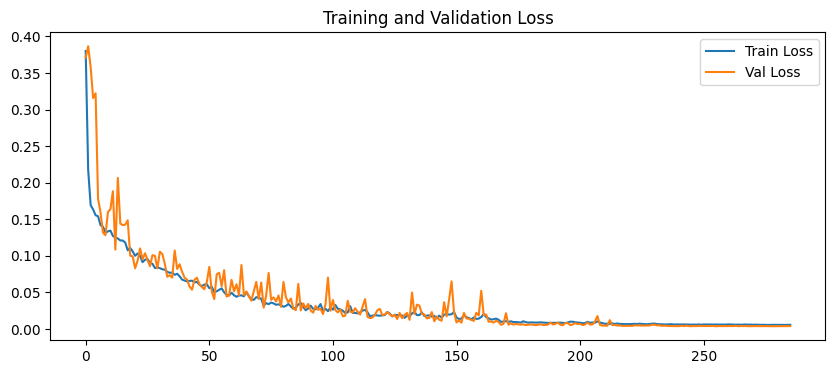

In [9]:
# Predict on test data
y_pred_s = model_inverse.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s)

# Print accuracy for each dimension
print("\nAccuracy Summary (MAPE per Dimension):")
mape_errors = []
for i, name in enumerate(DIM_NAMES):
    error = np.mean(np.abs((y_test[:, i] - y_pred[:, i]) / y_test[:, i])) * 100
    mape_errors.append(error)
    print(f"- {name:<20}: {error:.2f}%")

total_mape = np.mean(mape_errors)
print(f"\nTotal Average MAPE: {total_mape:.2f}%")

# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step
--- Testing Inverse Model Prediction (Index: 301) ---
Dimension            | Actual       | Predicted    | Error %
----------------------------------------------------------------------
Length               | 50.0000      | 49.9478      | 0.10%
Diameter             | 18.0000      | 18.2255      | 1.25%
Core_Diameter        | 14.0000      | 14.1150      | 0.82%
Rod_Diameter         | 1.0000       | 1.0981       | 9.81%
Support_Diameter     | 0.0000       | -0.0006      | inf%
Throat_Diameter      | 3.0000       | 2.9918       | 0.27%
Exit_Diameter        | 4.5000       | 4.4862       | 0.31%


/tmp/ipykernel_57/2567332206.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  error = abs(actual_dims[i] - predicted_dims[i]) / actual_dims[i] * 100


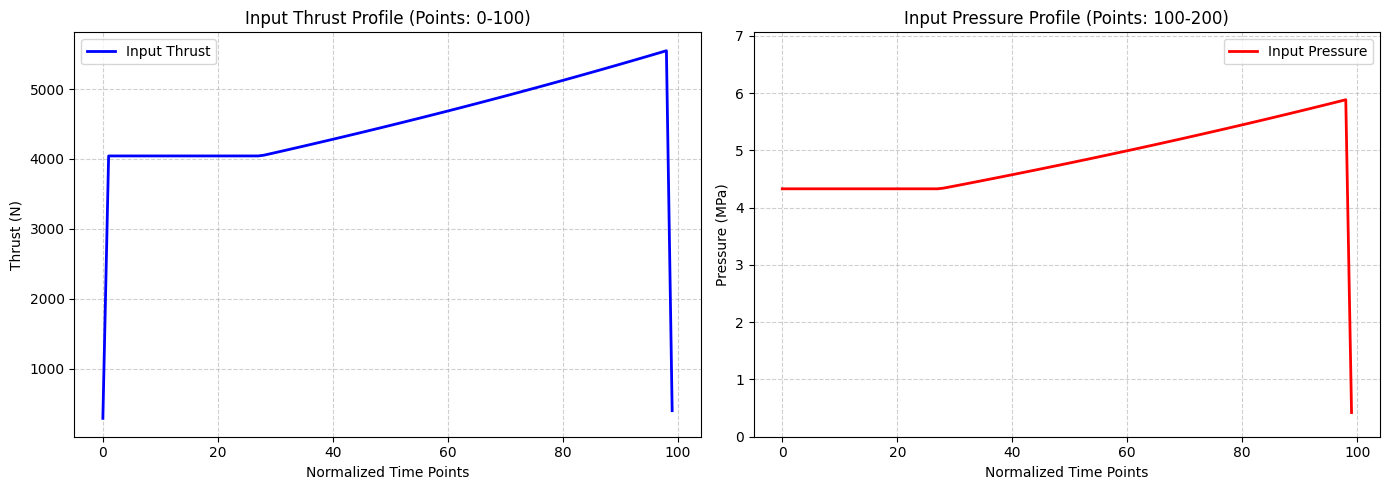

In [10]:
# --- Final Corrected Test Cell ---

# 1. Select a random sample from the test set and predict
test_index = np.random.randint(0, len(X_test_s))
sample_input = X_test_s[test_index : test_index + 1]
actual_dims = y_test[test_index]

# Perform prediction using the inverse model
predicted_dims_scaled = model_inverse.predict(sample_input)
# Invert the scaling to get real-world dimension values
predicted_dims = scaler_y.inverse_transform(predicted_dims_scaled)[0]

# 2. Print Evaluation Table for Geometric Dimensions
print(f"--- Testing Inverse Model Prediction (Index: {test_index}) ---")
print(f"{'Dimension':<20} | {'Actual':<12} | {'Predicted':<12} | {'Error %'}")
print("-" * 70)

for i, name in enumerate(DIM_NAMES):
    # Calculate Percentage Error for each dimension
    error = abs(actual_dims[i] - predicted_dims[i]) / actual_dims[i] * 100
    print(f"{name:<20} | {actual_dims[i]:<12.4f} | {predicted_dims[i]:<12.4f} | {error:.2f}%")

# 3. Visualization of Input Curves (Thrust & Pressure)
plt.figure(figsize=(14, 5))
full_data = X_test[test_index]
total_len = len(full_data)
mid_point = total_len // 2  # Split point between Thrust and Pressure data

# --- Thrust Plot (First 100 points) ---
plt.subplot(1, 2, 1)
plt.plot(full_data[:mid_point], color='blue', linewidth=2, label='Input Thrust')
plt.title(f"Input Thrust Profile (Points: 0-{mid_point})")
plt.xlabel("Normalized Time Points")
plt.ylabel("Thrust (N)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Pressure Plot (Last 100 points) ---
plt.subplot(1, 2, 2)
if total_len > mid_point:
    pressure_data = full_data[mid_point:]
    plt.plot(pressure_data, color='red', linewidth=2, label='Input Pressure')

    # Dynamic axis limit for better visibility
    if pressure_data.size > 0 and np.max(pressure_data) > 0:
        plt.ylim(0, np.max(pressure_data) * 1.2)

    plt.title(f"Input Pressure Profile (Points: {mid_point}-{total_len})")
    plt.xlabel("Normalized Time Points")
    plt.ylabel("Pressure (MPa)")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Data Error: Missing Pressure Segment", ha='center')
    plt.title("Pressure Profile (Unavailable)")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
# --- Save Model and Scalers Cell ---

# 1. Save the trained Keras model
# We save it in .h5 or .keras format
model_filename = 'inverse_rocket_model.keras'
model_inverse.save(model_filename)
print(f"✅ Model saved successfully as: {model_filename}")

# 2. Save the Scalers using joblib
# This is crucial because you must use the EXACT same scaling parameters for new data

# Save the Input Scaler (X)
joblib.dump(scaler_X, 'scaler_X_inverse.pkl')

# Save the Output Scaler (y)
joblib.dump(scaler_y, 'scaler_y_inverse.pkl')

print("✅ Scalers saved successfully: scaler_X_inverse.pkl and scaler_y_inverse.pkl")

# --- Optional: How to Load Them Later ---


✅ Model saved successfully as: inverse_rocket_model.keras
✅ Scalers saved successfully: scaler_X_inverse.pkl and scaler_y_inverse.pkl
